# 580 — Data science: understand the numbers AI produces
Original synthetic teaching exercises. Read `../lessons/580.md` alongside this notebook.

Each numbered section starts from its own data and imports; run the cells in that section in order. Predict before execution. Embedded outputs are the reference run, not a substitute for your explanation. No network, real scans, or LLM calls are needed.

## 580.1 — Arrays and axes
**Predict:** What is the shape after averaging the last axis of `(4,5,3,8)`? What information disappears?

Input/output: (4, 5, 3, 8) (4, 5, 3)
First voxel mean: 3.5


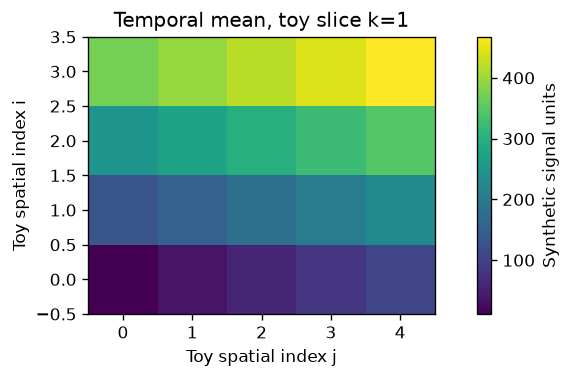

In [1]:
import numpy as np
import matplotlib.pyplot as plt
data = np.arange(4 * 5 * 3 * 8, dtype=float).reshape(4, 5, 3, 8)
mean_image = data.mean(axis=3)
print("Input/output:", data.shape, mean_image.shape)
print("First voxel mean:", mean_image[0, 0, 0])
assert mean_image.shape == (4, 5, 3)
assert mean_image[0, 0, 0] == 3.5
assert np.isfinite(mean_image).all()
plt.imshow(mean_image[:, :, 1], origin="lower", cmap="viridis")
plt.xlabel("Toy spatial index j")
plt.ylabel("Toy spatial index i")
plt.title("Temporal mean, toy slice k=1")
plt.colorbar(label="Synthetic signal units")
plt.show()

In [2]:
wrong = data.mean()
print("Wrong output shape:", np.shape(wrong))
assert np.shape(wrong) == ()  # Detects the intended failure, does not endorse it.
other_axis = data.mean(axis=0)
assert other_axis.shape == (5, 3, 8)
print("Mean over axis 0:", other_axis.shape)

Wrong output shape: ()
Mean over axis 0: (5, 3, 8)


**Interpret:** The scalar is a valid global mean but cannot be a temporal-mean image. This ramp is not brain anatomy. Change one axis, predict, then undo the change. Deliver a transformation card.

## 580.2 — Join by identity
**Predict:** Why can a table retain its shape while mixing participants?

In [3]:
import pandas as pd
scans = pd.DataFrame({"participant_id": ["p1", "p2", "p3"], "roi": [1., 2., 3.]})
scores = pd.DataFrame({"participant_id": ["p2", "p1", "p3"], "score": [20, 10, 30]})
joined = scans.merge(scores, on="participant_id", validate="one_to_one", indicator=True)
print(joined.to_string(index=False))
assert joined["score"].tolist() == [10, 20, 30]
wrong = scans.assign(score=scores["score"].to_numpy())
print("Wrong positional scores:", wrong["score"].tolist())
assert wrong["score"].tolist() != joined["score"].tolist()

participant_id  roi  score _merge
            p1  1.0     10   both
            p2  2.0     20   both
            p3  3.0     30   both
Wrong positional scores: [20, 10, 30]


In [4]:
duplicated = pd.concat([scores, scores.iloc[[0]]], ignore_index=True)
try:
    scans.merge(duplicated, on="participant_id", validate="one_to_one")
except pd.errors.MergeError:
    print("Expected: duplicate IDs rejected.")
else:
    raise AssertionError("Duplicate-ID protection failed")
missing = scans.merge(scores.iloc[1:], on="participant_id", how="left", indicator=True)
print("Unmatched:", missing.loc[missing["_merge"] == "left_only", "participant_id"].tolist())
assert missing.loc[missing["_merge"] == "left_only", "participant_id"].tolist() == ["p2"]

Expected: duplicate IDs rejected.
Unmatched: ['p2']


**Interpret:** The one-to-one assumption is appropriate only because this toy has one scan per person. In repeated visits choose the correct composite key. Missing is not zero.

## 580.3 — Standardization
**Predict:** Does changing the scale make a scientific hypothesis significant?

In [5]:
import numpy as np
x = np.array([2., 4., 6.])
center, scale = x.mean(), x.std(ddof=0)
assert scale > 0
z = (x - center) / scale
print("mean/SD:", center, scale, "z:", z)
assert np.isclose(z.mean(), 0)
assert np.isclose(z.std(ddof=0), 1)
assert np.allclose(z * scale + center, x)
z_sample = (x - x.mean()) / x.std(ddof=1)
print("ddof=1:", z_sample)
assert np.allclose(z_sample, [-1, 0, 1])

mean/SD: 4.0 1.632993161855452 z: [-1.2247  0.      1.2247]
ddof=1: [-1.  0.  1.]


In [6]:
constant = np.ones(3)
if constant.std(ddof=0) == 0:
    print("Flag: zero-variance vector; direct z formula undefined.")
columns = np.column_stack([x, 10 * x + 50])
per_feature = (columns - columns.mean(axis=0)) / columns.std(axis=0)
pooled = (columns - columns.mean()) / columns.std()
assert np.allclose(per_feature[:, 0], per_feature[:, 1])
print("Feature-wise means:", per_feature.mean(axis=0))
print("Pooled means by feature:", pooled.mean(axis=0))

Flag: zero-variance vector; direct z formula undefined.
Feature-wise means: [0. 0.]
Pooled means by feature: [-0.9655  0.9655]


**Interpret:** Axis and reference population are part of the method. These z values are descriptive, not inferential z statistics. Explain what must be saved to reconstruct the original units.

## 580.4 — Regression and residuals
**Predict:** What coefficients generate `y = 2 + 3*x`? Name the design columns first.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
x = np.arange(6, dtype=float)
y = 2 + 3 * x
X = np.column_stack([np.ones(len(x)), x])
beta = np.linalg.lstsq(X, y, rcond=None)[0]
fitted = X @ beta
residual = y - fitted
print("Columns: intercept, x. Coefficients:", beta)
assert np.allclose(beta, [2, 3])
assert np.allclose(residual, 0)
assert np.allclose(y, fitted + residual)
X_months = np.column_stack([np.ones(len(x)), 12 * x])
assert np.allclose(np.linalg.lstsq(X_months, y, rcond=None)[0], [2, .25])

Columns: intercept, x. Coefficients: [2. 3.]


Slope without intercept: 3.5454545454545454


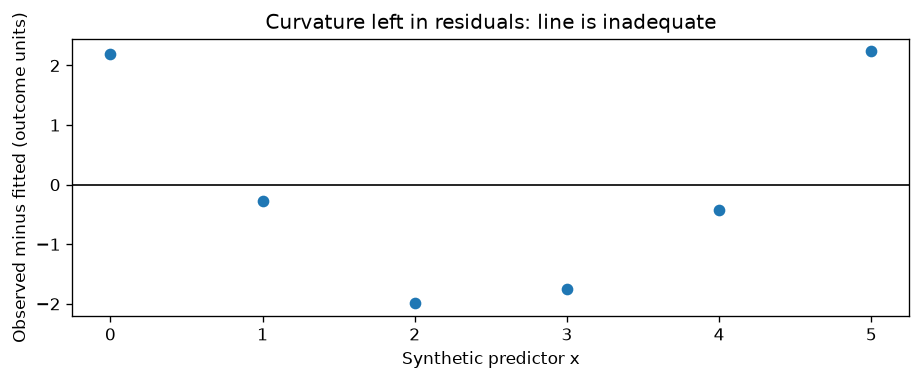

In [8]:
rng = np.random.default_rng(5804)
y_curve = 2 + 3 * x + .7 * (x - 2.5) ** 2 + rng.normal(0, .1, len(x))
fit_curve = X @ np.linalg.lstsq(X, y_curve, rcond=None)[0]
plt.scatter(x, y_curve - fit_curve)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Synthetic predictor x")
plt.ylabel("Observed minus fitted (outcome units)")
plt.title("Curvature left in residuals: line is inadequate")
plt.show()
wrong_slope = np.linalg.lstsq(x[:, None], y, rcond=None)[0][0]
print("Slope without intercept:", wrong_slope)
assert not np.isclose(wrong_slope, 3)

**Interpret:** The residual's pattern challenges the model. A fitted slope is not automatically causal; a zero residual is not proof of scientific validity.

## 580.5 — QC, spread, and uncertainty
**Predict:** How does adding 100 change the mean and median? Does it prove 100 must be excluded?

Original mean: 3.0
With 100, mean/median: 19.166666666666668 3.5


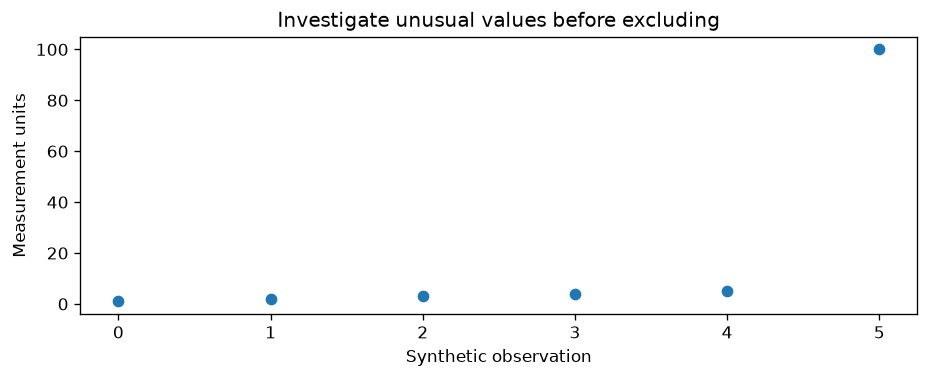

In [9]:
import numpy as np
import matplotlib.pyplot as plt
x = np.array([1., 2., 3., 4., 5.])
with_outlier = np.append(x, 100.)
print("Original mean:", x.mean())
print("With 100, mean/median:", with_outlier.mean(), np.median(with_outlier))
assert x.mean() == 3
assert np.isclose(with_outlier.mean(), 115 / 6)
assert np.median(with_outlier) == 3.5
plt.scatter(np.arange(len(with_outlier)), with_outlier)
plt.xlabel("Synthetic observation")
plt.ylabel("Measurement units")
plt.title("Investigate unusual values before excluding")
plt.show()

In [10]:
rng = np.random.default_rng(5805)
spreads = {}
for n in [10, 100]:
    sample_means = rng.normal(0, 2, (5000, n)).mean(axis=1)
    spreads[n] = sample_means.std(ddof=1)
    print("n, empirical SE, theoretical SE:", n, spreads[n], 2 / np.sqrt(n))
    assert np.isclose(spreads[n], 2 / np.sqrt(n), rtol=.08)
assert spreads[100] < spreads[10]
print("This assumes independent synthetic observations.")

n, empirical SE, theoretical SE: 10 0.6302977377360338 0.6324555320336759
n, empirical SE, theoretical SE: 100 0.1965443921259318 0.2
This assumes independent synthetic observations.


**Interpret:** Population spread stayed fixed; uncertainty of the sample mean decreased. Repeated measurements from one participant are not automatically independent participants. Propose a QC rule before inspecting its effect on a group comparison.

## 580.6 — Leakage and provenance
**Predict:** Which mean should an unseen participant's feature be compared with?

In [11]:
import numpy as np
from sklearn.preprocessing import StandardScaler
train = np.array([[0.], [2.], [4.]])
test = np.array([[100.], [102.]])
scaler = StandardScaler().fit(train)
train_z, test_z = scaler.transform(train), scaler.transform(test)
leaky = StandardScaler().fit(np.vstack([train, test]))
print("Correct/leaky fitted mean:", scaler.mean_, leaky.mean_)
print("Test standardized values:", test_z.ravel())
assert np.allclose(scaler.mean_, [2])
assert np.allclose(leaky.mean_, [41.6])
assert np.isclose(train_z.mean(), 0)
assert not np.isclose(test_z.mean(), 0)

Correct/leaky fitted mean: [2.] [41.6]
Test standardized values: [60.0125 61.2372]


In [12]:
import json, platform
from importlib.metadata import version
record = {"exercise": "580.6", "data": "synthetic fixed arrays in this notebook",
          "fit_scope": "training rows only", "mean": scaler.mean_.tolist(),
          "scale": scaler.scale_.tolist(), "random_seed": None,
          "python": platform.python_version(),
          "packages": {k: version(k) for k in ["numpy", "scikit-learn"]},
          "ai": "reference code; no LLM executed by this notebook"}
record_text = json.dumps(record, indent=2)
print(record_text)
assert json.loads(record_text)["mean"] == [2.0]

{
  "exercise": "580.6",
  "data": "synthetic fixed arrays in this notebook",
  "fit_scope": "training rows only",
  "mean": [
    2.0
  ],
  "scale": [
    1.632993161855452
  ],
  "random_seed": null,
  "python": "3.14.7",
  "packages": {
    "numpy": "2.5.3",
    "scikit-learn": "1.9.1"
  },
  "ai": "reference code; no LLM executed by this notebook"
}


**Interpret:** Copy the record into your analysis log and add your actual tutor/provider and prompt. Here no randomness was used, so a fabricated seed would add no value. Restart and run all; provenance and correctness are separate responsibilities.